In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt 
import matplotlib.pyplot as plt 


In [1]:
import pandas as pd
df=pd.read_csv("monitor_data.csv")
df.head(700)

,Time,Voltage(V),Current(A),Power(W),Leakage Current(mA),total_forward_energy(kWh),price(DZD)
0,2025-08-12 22:30:01,355.92,7.68,24.2,0,16.60,88.5372
1,2025-08-12 22:30:11,343.12,7.68,22.2,0,16.60,88.5372
2,2025-08-12 22:30:21,358.48,7.68,21.2,0,16.60,88.5372
3,2025-08-12 22:30:31,373.84,7.68,20.2,0,16.60,88.5372
4,2025-08-12 22:30:41,373.84,7.68,20.2,0,16.60,88.5372
...,...,...,...,...,...,...,...
695,2025-08-13 00:28:12,320.08,12.80,0.0,0,17.13,88.5372
696,2025-08-13 00:28:22,307.28,12.80,3.0,0,17.13,88.5372
697,2025-08-13 00:28:32,317.52,12.80,10.0,0,17.13,88.5372
698,2025-08-13 00:28:43,322.64,10.24,23.6,0,17.13,88.5372


In [2]:
df.shape 

(707, 7)

In [3]:
df.columns

Index(['Time', 'Voltage(V)', 'Current(A)', 'Power(W)', 'Leakage Current(mA)',
       'total_forward_energy(kWh)', 'price(DZD)'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707 entries, 0 to 706
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time                       707 non-null    object 
 1   Voltage(V)                 707 non-null    float64
 2   Current(A)                 707 non-null    float64
 3   Power(W)                   707 non-null    float64
 4   Leakage Current(mA)        707 non-null    int64  
 5   total_forward_energy(kWh)  707 non-null    float64
 6   price(DZD)                 707 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 38.8+ KB


In [5]:
df.describe()

,Voltage(V),Current(A),Power(W),Leakage Current(mA),total_forward_energy(kWh),price(DZD)
count,707.000000,707.000000,707.000000,707.0,707.000000,707.0000
mean,380.306987,13.697992,14.035644,0.0,16.898812,88.5372
std,34.567488,8.163376,7.638621,0.0,0.163782,0.0000
min,289.360000,5.120000,0.000000,0.0,16.600000,88.5372
25%,359.760000,7.680000,7.200000,0.0,16.770000,88.5372
50%,381.520000,10.240000,15.600000,0.0,16.940000,88.5372
75%,407.120000,17.920000,20.800000,0.0,17.040000,88.5372
max,460.880000,51.200000,25.200000,0.0,17.130000,88.5372


In [6]:
#Are there any missing values? Use df.isnull().sum()
print (df.isnull().sum())

Time                         0
Voltage(V)                   0
Current(A)                   0
Power(W)                     0
Leakage Current(mA)          0
total_forward_energy(kWh)    0
price(DZD)                   0
dtype: int64


In [7]:
#Are there any duplicates? Remove them if found.
print(df.duplicated().sum())

0


In [8]:
df.groupby("total_forward_energy(kWh)")[["price(DZD)"]].mean()

,price(DZD)
total_forward_energy(kWh),
16.60,88.5372
16.61,88.5372
16.62,88.5372
16.63,88.5372
16.64,88.5372
16.65,88.5372
16.66,88.5372
16.67,88.5372
16.68,88.5372


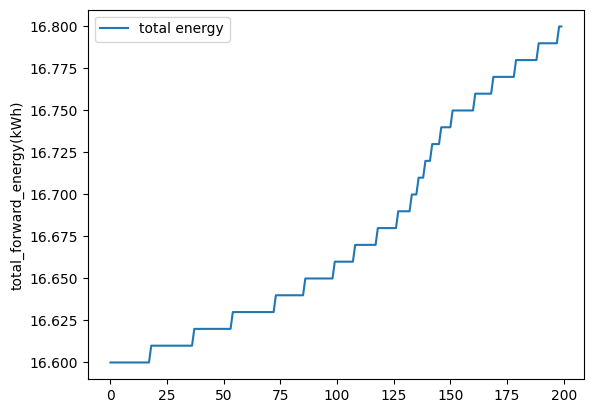

In [9]:



import matplotlib.pyplot as plt 
plt.plot(df["total_forward_energy(kWh)"][:200] , label = "total energy" )
#plt.title("Reading vs Writing Scores (First 10 Students)")
plt.ylabel("total_forward_energy(kWh)")
plt.legend()
plt.show()

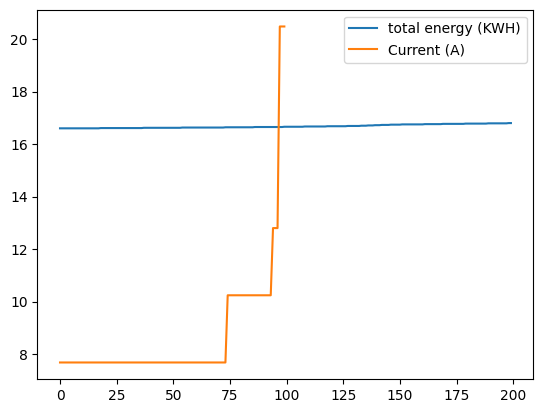

In [10]:
import matplotlib.pyplot as plt 
plt.plot(df["total_forward_energy(kWh)"][:200] , label = "total energy (KWH)" )
plt.plot(df["Current(A)"][:100] , label = "Current (A)" )
#plt.title("Reading vs Writing Scores (First 10 Students)")
plt.legend()
plt.show()

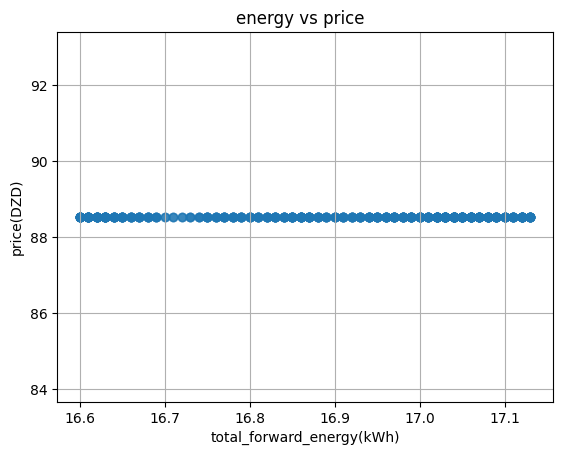

In [11]:
plt.scatter(df["total_forward_energy(kWh)"], df["price(DZD)"], alpha=0.5)
plt.title("energy vs price  ")
plt.xlabel("total_forward_energy(kWh)")
plt.ylabel("price(DZD)")
plt.grid(True) 
plt.show()

Superviced Machine Learning

prediction :  [[16.92947714]
 [16.8922329 ]
 [16.85498866]
 [16.81774442]
 [16.88691229]]
mean_squared_error: 0.024481937595822893


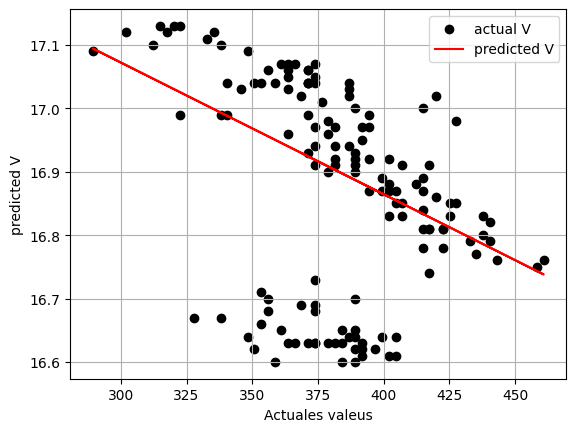

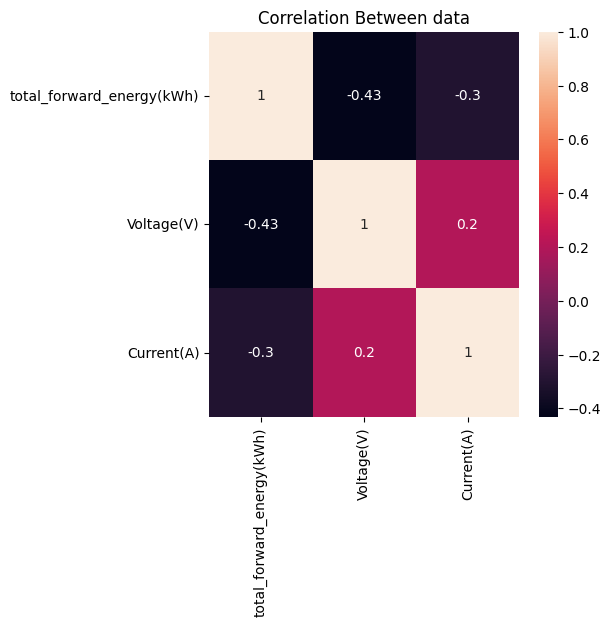

In [12]:
# LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 
import seaborn as sns

X = df["Voltage(V)"].values.reshape(-1,1)
y = df["total_forward_energy(kWh)"].values.reshape(-1,1)

X_train ,X_test , y_train , y_test = train_test_split(X ,y , test_size=0.2 , random_state= 42)

model=LinearRegression()
model.fit( X_train , y_train)

y_pred = model.predict(X_test)
print( "prediction : " , y_pred[:5])


mse = mean_squared_error(y_test , y_pred)
print("mean_squared_error:" , mse)

plt.scatter(X_test, y_test, color="black" , label="actual V")
plt.plot(X_test, y_pred , color = "red" , label= "predicted V")
plt.xlabel("Actuales valeus")
plt.ylabel("predicted V")
#plt.title("linear Regression for ")
plt.legend()
plt.grid(True)
plt.show()


# correlation between data's 
df[['total_forward_energy(kWh)' ,'Voltage(V)' , 'Current(A)']].corr()

plt.figure(figsize=(5, 5))
sns.heatmap(df[[ 'total_forward_energy(kWh)' ,'Voltage(V)' , 'Current(A)' ]].corr(), annot=True)
plt.title("Correlation Between data")
plt.show()

In [13]:
model=LinearRegression()
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# correlation between data's 
df[['total_forward_energy(kWh)' ,'Voltage(V)' , 'Current(A)']].corr()

,total_forward_energy(kWh),Voltage(V),Current(A)
total_forward_energy(kWh),1.000000,-0.431152,-0.304578
Voltage(V),-0.431152,1.000000,0.198805
Current(A),-0.304578,0.198805,1.000000


In [15]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

CSV_FILE = "monitor_data.csv" 
df = pd.read_csv(CSV_FILE)

X = df[["Voltage(V)", "Current(A)"]] 
y = df["Power(W)"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} W")
print(f"R² Score: {r2:.2f}")

new_voltage = 220
new_current = 3.5
predicted_power = model.predict([[new_voltage, new_current]])[0]
print(f"Predicted Power: {predicted_power:.2f} W")

Mean Absolute Error: 4.61 W
R² Score: 0.24
Predicted Power: 10.24 W


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [16]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# 1. Load & Prepare Data 
CSV_FILE ="monitor_data.csv"
df = pd.read_csv(CSV_FILE, parse_dates=["Time"])
df = df.sort_values("Time").set_index("Time").asfreq("10S")  # match sampling rate
df["Power(W)"] = df["Power(W)"].interpolate(limit_direction="both")

# 2. Predict 5 minutes ahead
HORIZON = 30  # 10 * 30s = 5 minutes
df["target"] = df["Power(W)"].shift(-HORIZON)
df = df.dropna()

X = df.drop(columns=["target"])
y = df["target"]

# . Time-Aware Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
best_model = None
best_mpae = float("inf")

for depth in [3, 5, 7]:
    model = GradientBoostingRegressor(n_estimators=200, max_depth=depth, random_state=42)
    mpaes = []
    for train_idx, test_idx in tscv.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[test_idx])
        mpaes.append(mean_absolute_error(y.iloc[test_idx], preds))
    avg_mpae = np.mean(mpaes)
    print(f"Depth={depth} | CV MAE={avg_mpae:.2f} W")
    if avg_mpae < best_mpae:
        best_mpae = avg_mpae
        best_model = model

# . Final Fit & Save
best_model.fit(X, y)
joblib.dump(best_model, "power_forecast_5min_gb.joblib")
print(f"Best CV MPAE: {best_mpae:.2f} W")



C:\Users\dell\AppData\Local\Temp\ipykernel_8676\476051804.py:12: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.sort_values("Time").set_index("Time").asfreq("10S")  # match sampling rate


Depth=3 | CV MAE=4.04 W
Depth=5 | CV MAE=4.97 W
Depth=7 | CV MAE=5.05 W
Best CV MPAE: 4.04 W


C:\Users\dell\AppData\Local\Temp\ipykernel_8676\884569696.py:12: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.sort_values("Time").set_index("Time").asfreq("10S")  # match sampling rate


Depth=3 | CV MAE=0.37 W
Depth=5 | CV MAE=0.46 W
Depth=7 | CV MAE=0.47 W
Best CV MPAE: 0.37 W


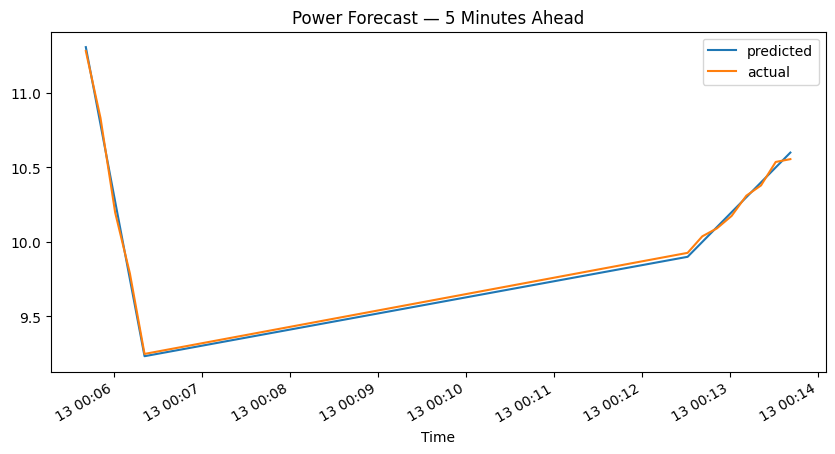

In [18]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import  mean_absolute_percentage_error , mean_absolute_error

# 1. Load & Prepare Data 
CSV_FILE ="monitor_data.csv"
df = pd.read_csv(CSV_FILE, parse_dates=["Time"])
df = df.sort_values("Time").set_index("Time").asfreq("10S")  # match sampling rate
df["Power(W)"] = df["Power(W)"].interpolate(limit_direction="both")

# 2. Predict 5 minutes ahead
HORIZON = 30  # 10 * 30s = 5 minutes
df["target"] = df["Power(W)"].shift(-HORIZON)
df = df.dropna()

X = df.drop(columns=["target"])
y = df["target"]

# 3. Time-Aware Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
best_model = None
best_mpae = float("inf")

for depth in [3, 5, 7]:
    model = GradientBoostingRegressor(n_estimators=200, max_depth=depth, random_state=42)
    mpaes = []
    for train_idx, test_idx in tscv.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X.iloc[test_idx])
        mpaes.append(mean_absolute_percentage_error(y.iloc[test_idx], preds))
    avg_mpae = np.mean(mpaes)
    print(f"Depth={depth} | CV MAE={avg_mpae:.2f} W")
    if avg_mpae < best_mpae:
        best_mpae = avg_mpae
        best_model = model

# 4. Final Fit & Save
best_model.fit(X, y)
joblib.dump(best_model, "power_forecast_5min_gb.joblib")
print(f"Best CV MPAE: {best_mpae:.2f} W")

# 5. Holdout Evaluation
n_hold = int(len(X) * 0.2)
y_hold = y.iloc[-n_hold:]
X_hold = X.iloc[-n_hold:]
y_pred = best_model.predict(X_hold)



# 6. Plot Results
plt.figure(figsize=(10,5))
y_hold.plot(label="predicted")
pd.Series(y_pred, index=y_hold.index).plot(label="actual")
plt.legend()
plt.title("Power Forecast — 5 Minutes Ahead")
plt.show()

Usuperviced Machine Learning

Cluster 0 Center → Voltage=412.74V | Current=18.74A | Power=5.46W
Cluster 1 Center → Voltage=376.77V | Current=7.67A | Power=20.95W
Cluster 2 Center → Voltage=366.76V | Current=51.20A | Power=2.18W
Cluster 3 Center → Voltage=411.88V | Current=16.59A | Power=20.29W
Cluster 4 Center → Voltage=342.00V | Current=12.10A | Power=11.34W


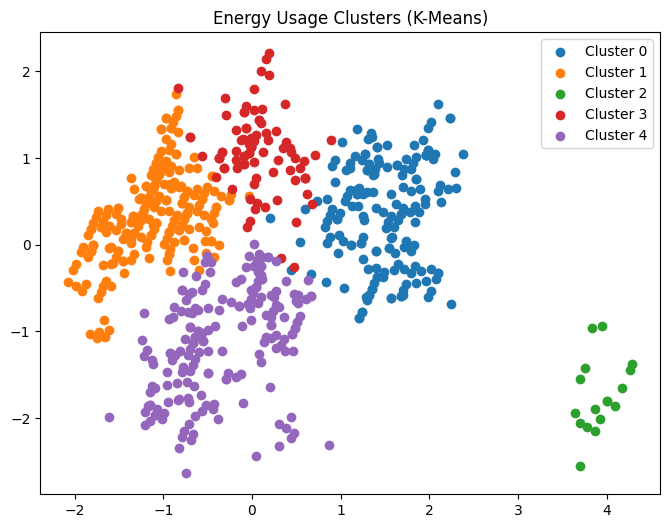

Detected 36 anomalies out of 707 readings


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load & Prepare Data

df = pd.read_csv(CSV_FILE, parse_dates=["Time"])
df = df.sort_values("Time").set_index("Time")

# Keep relevant features for clustering
features = ["Voltage(V)", "Current(A)", "Power(W)"]
df_feat = df[features].copy()



# 2. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feat)

# 3. K-Means Clustering

k = 5  # Low, Medium, High usage (3_5)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)


# 4. Cluster Centers (Profile)

cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i} Center → Voltage={center[0]:.2f}V | Current={center[1]:.2f}A | Power={center[2]:.2f}W")

# 5. Visualize Clusters (PCA to 2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for cluster_id in range(k):
    plt.scatter(X_pca[df["Cluster"] == cluster_id, 0],
                X_pca[df["Cluster"] == cluster_id, 1],
                label=f"Cluster {cluster_id}")
plt.title("Energy Usage Clusters (K-Means)")
plt.legend()
plt.show()


# 6. Anomaly Detection 

# Distance to nearest cluster center
distances = np.min(kmeans.transform(X_scaled), axis=1)
threshold = np.percentile(distances, 95)  # top 5% farthest = anomalies
df["Anomaly"] = distances > threshold

print(f"Detected {df['Anomaly'].sum()} anomalies out of {len(df)} readings")
